In [ ]:
# ------------1----------
df = pd.read_csv('Iris.csv')   # make sure file name matches

print("First 5 rows:")
display(df.head())

First 5 rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.columns = df.columns.str.strip().str.lower()
print("Columns:", df.columns)

df.drop(columns=['id'], errors='ignore', inplace=True)

Columns: Index(['sepallengthcm', 'sepalwidthcm', 'petallengthcm', 'petalwidthcm',
       'species'],
      dtype='object')


In [ ]:
# ------------2-----------
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

print("Encoded classes:", df['species'].unique())

Encoded classes: [0 1 2]


In [ ]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
sepallengthcm    0
sepalwidthcm     0
petallengthcm    0
petalwidthcm     0
species          0
dtype: int64


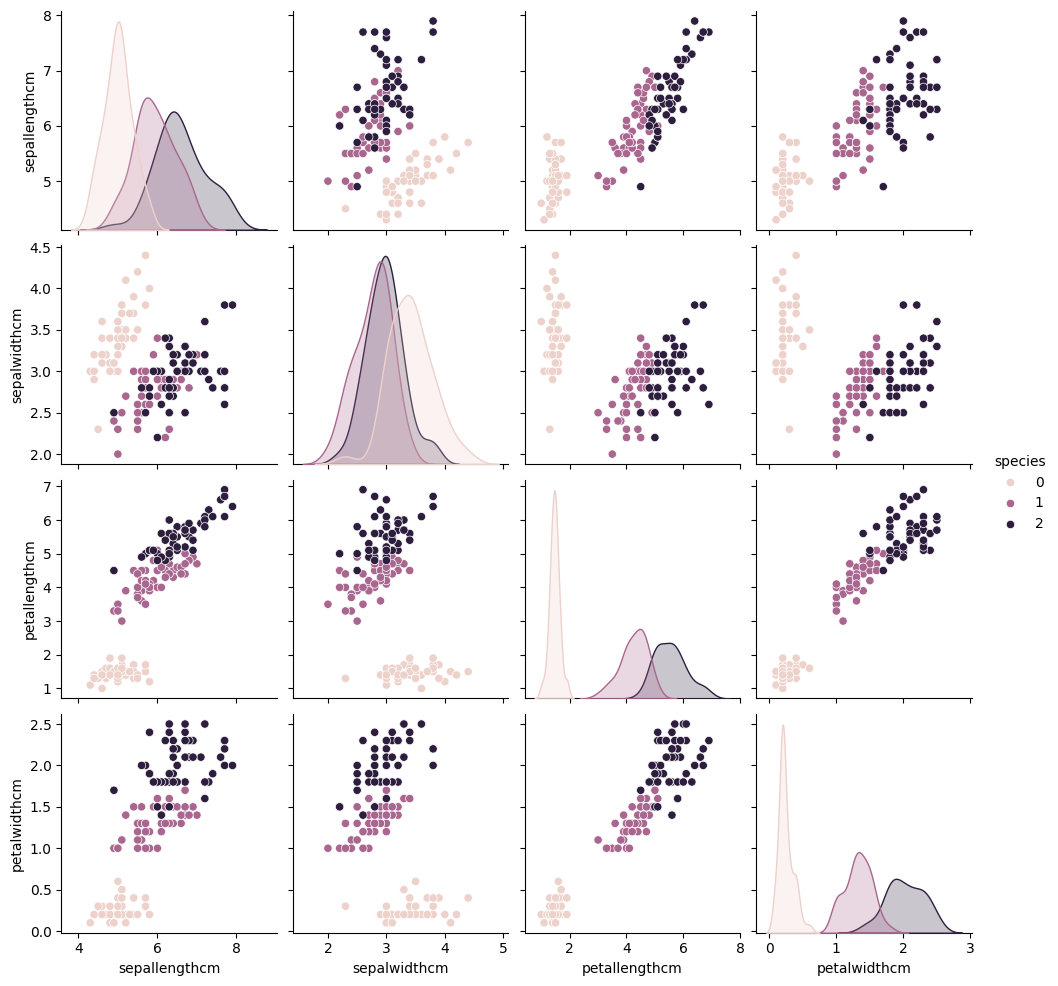

In [ ]:
# ------------3----------------
sns.pairplot(df, hue='species')
plt.show()

In [ ]:
# ------------4---------
X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (120, 4)
Test shape: (30, 4)


In [ ]:
model = GaussianNB()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [ ]:
# ------------5----------
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

display(comparison.head())

,Actual,Predicted
0,1,1
1,0,0
2,2,2
3,1,1
4,1,1


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [ ]:
# ------------6------------
TP = np.diag(cm)
FP = cm.sum(axis=0) - TP
FN = cm.sum(axis=1) - TP
TN = cm.sum() - (TP + FP + FN)

print("\nTP:", TP)
print("FP:", FP)
print("FN:", FN)
print("TN:", TN)


TP: [10  9 11]
FP: [0 0 0]
FN: [0 0 0]
TN: [20 21 19]


In [ ]:
#-----------7-----------
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

print("\nAccuracy:", accuracy)
print("Error Rate:", error_rate)


Accuracy: 1.0
Error Rate: 0.0


In [ ]:
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("\nPrecision:", precision)
print("Recall:", recall)


Precision: [1. 1. 1.]
Recall: [1. 1. 1.]


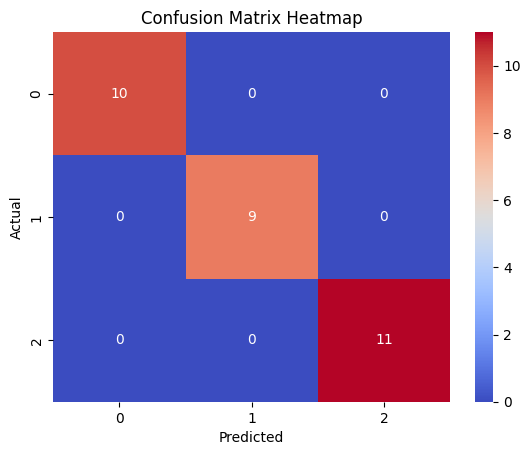

In [ ]:
# ------------8------------
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# ------------9------------
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

